In [2]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
dataset_path='PJME_hourly.csv'

In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sn

In [5]:
plt.style.use('fivethirtyeight')
sn.set_theme(style="whitegrid")

In [6]:
df=pd.read_csv(dataset_path, parse_dates=['Datetime'], index_col='Datetime')

In [7]:
df.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [8]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [9]:
df = df.sort_index()

In [10]:
df

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0
...,...
2018-08-02 20:00:00,44057.0
2018-08-02 21:00:00,43256.0
2018-08-02 22:00:00,41552.0


In [11]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 145366 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


In [12]:
print(f"Duplicate timestamps found: {df.index.duplicated().sum()}")

Duplicate timestamps found: 4


In [13]:
df = df[~df.index.duplicated(keep='first')]

In [14]:
print(f"New dataset row count: {len(df)}")

New dataset row count: 145362


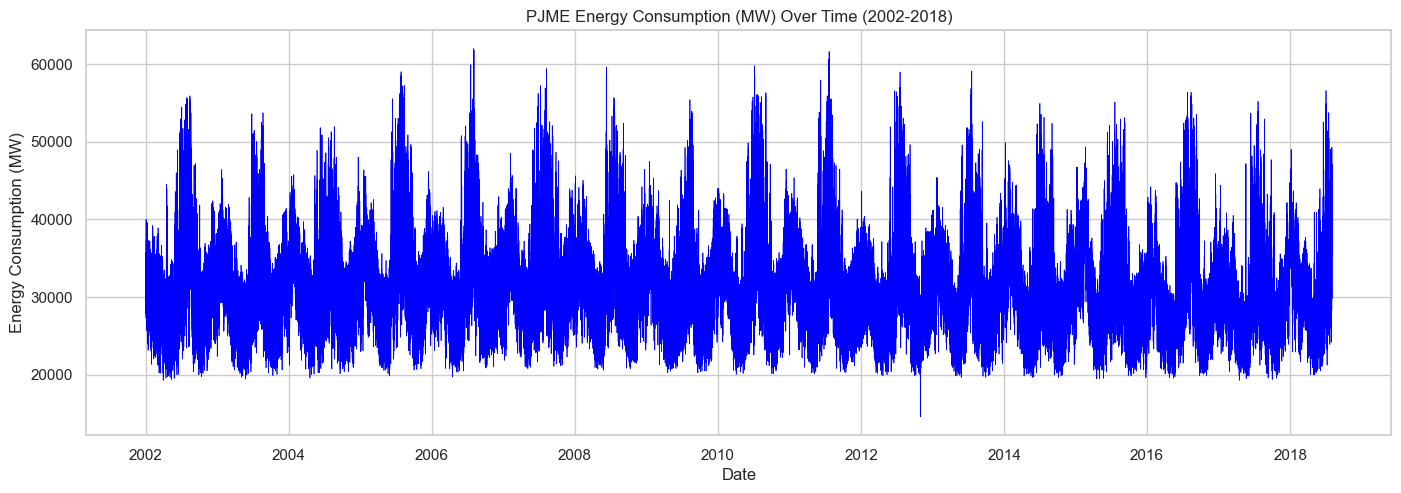

In [15]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df['PJME_MW'], color='blue', linewidth=0.5)
plt.title('PJME Energy Consumption (MW) Over Time (2002-2018)')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (MW)')
plt.show()

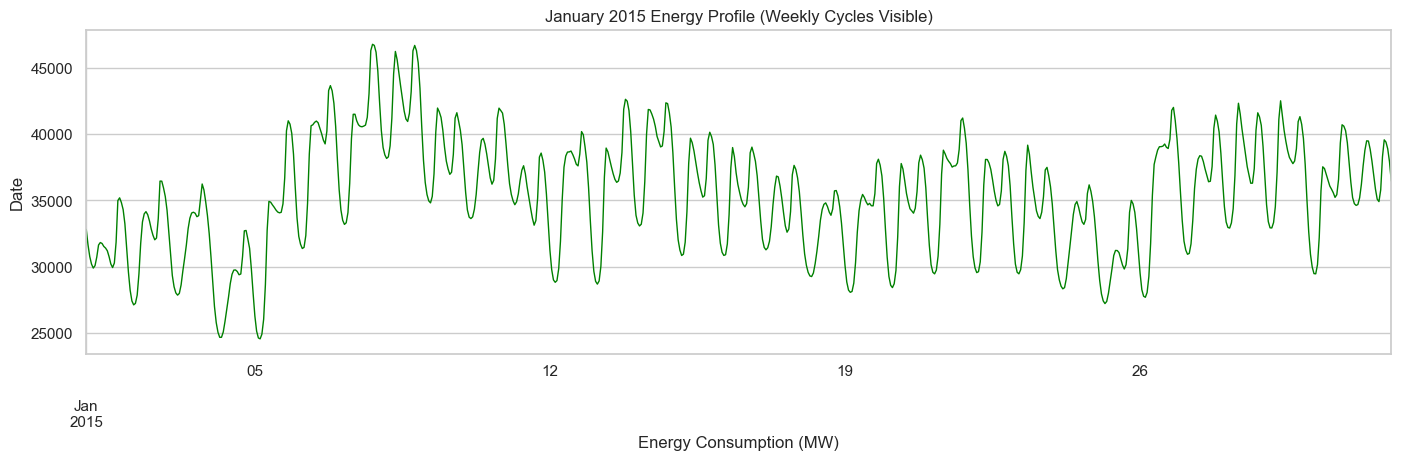

In [16]:
#1. Create a 1-Month Window Plot
plt.figure(figsize=(15,4))
df.loc['2015-01-01':'2015-01-31', 'PJME_MW'].plot(color='green', linewidth=1)
plt.title('January 2015 Energy Profile (Weekly Cycles Visible)')
plt.xlabel('Energy Consumption (MW)')
plt.ylabel('Date')
plt.show()

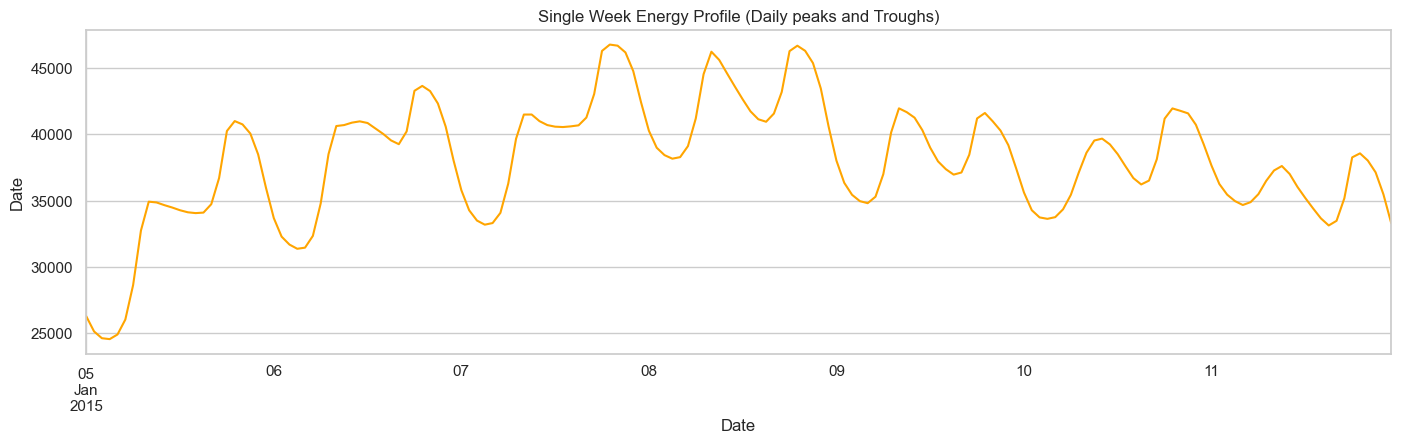

In [17]:
plt.figure(figsize=(15,4))
df.loc['2015-01-05':'2015-01-11','PJME_MW'].plot(color='orange', linewidth=1.5)
plt.title('Single Week Energy Profile (Daily peaks and Troughs)')
plt.xlabel('Date')
plt.ylabel('Date')
plt.show()

C:\Users\akhil\AppData\Local\Temp\ipykernel_44028\17924593.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.boxplot(data=df, x='hour',y='PJME_MW', palette='Blues')


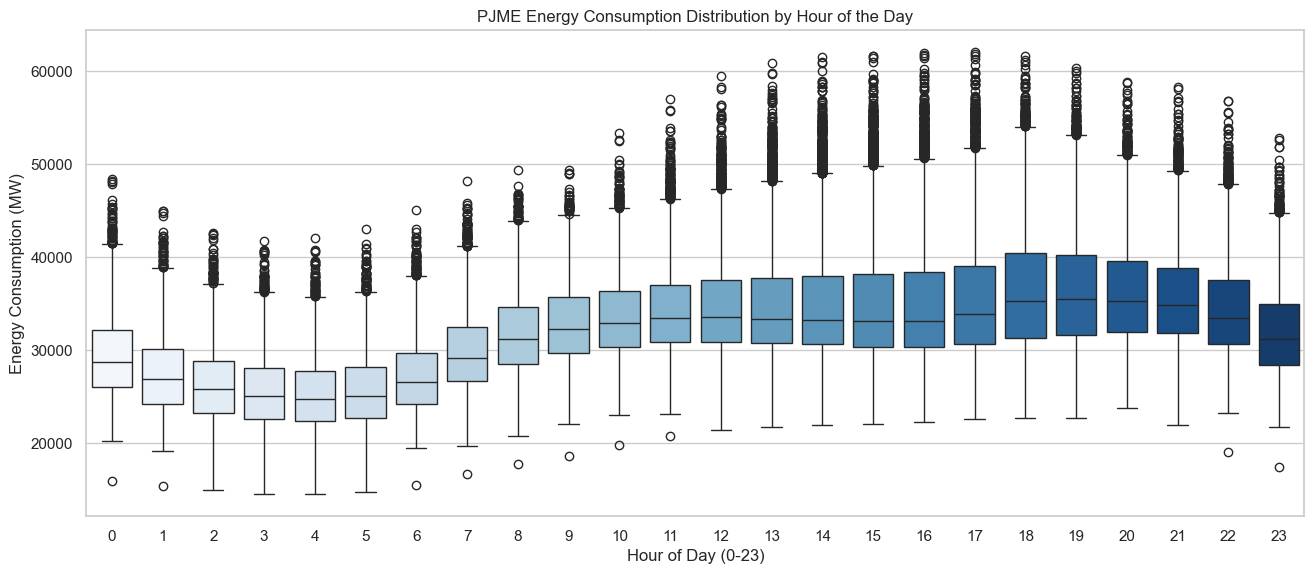

In [19]:
df['hour'] = df.index.hour
df['month'] = df.index.month

#2. Plot Energy Consumption by Hour of the day
plt.figure(figsize=(14,6))
sn.boxplot(data=df, x='hour',y='PJME_MW', palette='Blues')
plt.title('PJME Energy Consumption Distribution by Hour of the Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Energy Consumption (MW)')
plt.show()

In [21]:

df['month'] = df.index.month

C:\Users\akhil\AppData\Local\Temp\ipykernel_44028\4156275037.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.boxplot(data=df, x='month',y='PJME_MW', palette='Oranges')


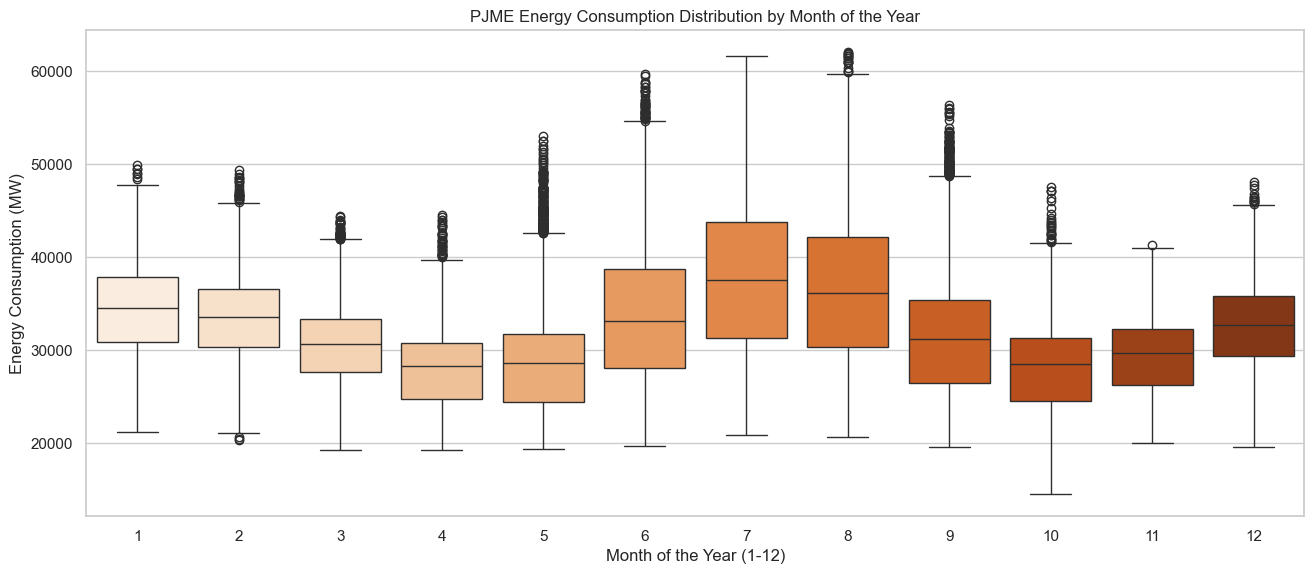

In [24]:
from matplotlib.pyplot import xlabel
#3. Plot Energy Consumption by Month of Year
plt.figure(figsize=(14,6))
sn.boxplot(data=df, x='month',y='PJME_MW', palette='Oranges')
plt.title('PJME Energy Consumption Distribution by Month of the Year')
plt.xlabel('Month of the Year (1-12)')
plt.ylabel('Energy Consumption (MW)')
plt.show()